# Classification: Customer Segmentation

The objective of this code is to classify customers into segments based on input features that represent customer characteristics. 

Step 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.model_selection import cross_val_score, GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [ ]:
train = pd.read_csv('customer_segmentation.train.csv')
valid = pd.read_csv('customer_segmentation.valid.csv')

Step 2. Train and evaluate classifiers with all available features

In [3]:
CLF = {} # dictionary of classifiers
CLF['GNB'] = GaussianNB()
CLF['DT'] = DecisionTreeClassifier()
CLF['RF'] = RandomForestClassifier()
CLF['ET'] = ExtraTreesClassifier()
CLF['AB'] =  AdaBoostClassifier()
CLF['SGD'] = SGDClassifier()
CLF['Ridge'] = RidgeClassifier()
CLF['LR'] = LogisticRegression(max_iter=1000)
CLF['Lin_SVC'] = LinearSVC()
CLF['SVC'] = SVC()
CLF['KNN'] = KNeighborsClassifier()
CLF['MLP'] = MLPClassifier()

print('Classifiers:')
for c in CLF:
    print(f'{c} : {CLF[c].__class__.__name__}')

Classifiers:
GNB : GaussianNB
DT : DecisionTreeClassifier
RF : RandomForestClassifier
ET : ExtraTreesClassifier
AB : AdaBoostClassifier
SGD : SGDClassifier
Ridge : RidgeClassifier
LR : LogisticRegression
Lin_SVC : LinearSVC
SVC : SVC
KNN : KNeighborsClassifier
MLP : MLPClassifier


In [4]:
features = list(train)[1:]
res = []

for c in CLF:
    model = CLF[c]
    score = cross_val_score(model, train[features], train.y).mean()
    print(c, round(score,4))
    res.append([c, score])
pd.DataFrame(res, columns=['model', 'score']).round(4)

GNB 0.8381
DT 0.8848
RF 0.944
ET 0.9494
AB 0.8463
SGD 0.8704
Ridge 0.8772
LR 0.897
Lin_SVC 0.8878
SVC 0.9572
KNN 0.9462
MLP 0.9098


,model,score
0,GNB,0.8381
1,DT,0.8848
2,RF,0.9440
3,ET,0.9494
4,AB,0.8463
5,SGD,0.8704
6,Ridge,0.8772
7,LR,0.8970
8,Lin_SVC,0.8878
9,SVC,0.9572


Step 3. Eliminate irrelevant features

Using the '*feature_importances_*' attribute of a trained *ExtraTreesClassifier* model, we can estimate the importance of each feature, sort them based on importance and check if some can be dropped due to irrelevance.

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
importance,0.158,0.144,0.114,0.09,0.075,0.06,0.059,0.021,0.007,0.007,0.007,0.007,0.007,0.007,0.007,0.007,0.007,0.007,0.007,0.007
feature,x15,x20,x13,x37,x43,x16,x27,x6,x10,x9,x50,x5,x25,x12,x36,x22,x26,x35,x41,x28


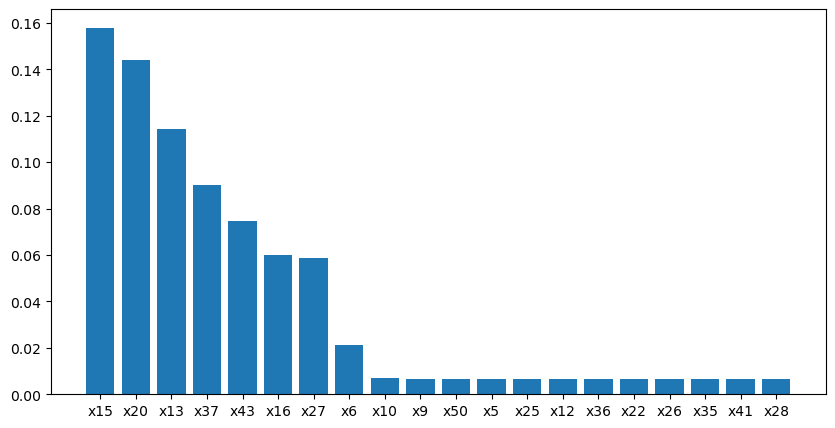

In [5]:
ET = ExtraTreesClassifier().fit(train[features], train.y) # Train ExtraTreesClassifier
fi = sorted([(imp, f) for imp, f in zip(ET.feature_importances_, features)], reverse=True) # features sorted in descending order of importance
k = 20 # consider the k most important features (change as desired)
plt.figure(figsize=(10, 5)) # size of figure to be displayed
_ = plt.bar([v[1] for v in fi][:k], [v[0] for v in fi][:k]) # plot importance
pd.DataFrame(fi[:k], columns=['importance', 'feature']).round(3).T # show importance

We identify a list of *relevant_features* and then use only these relevant features to train models.

In [6]:
k = 11
relevant_features = [v[1] for v in fi][:k] 
print("Relevant features:", ', '.join(relevant_features))

Relevant features: x15, x20, x13, x37, x43, x16, x27, x6, x10, x9, x50


Step 4. Evaluate models using relevant features

In [8]:
res = []

for c in CLF:
    model = CLF[c]
    score = cross_val_score(model, train[relevant_features], train.y).mean()
    print(c, round(score,4))
    res.append([c, score])
res_df = pd.DataFrame(res, columns=['model', 'mean accuracy']).round(4)
#res_df.to_csv('cross_validation_results.csv', index=False)
res_df

GNB 0.8382
DT 0.8999
RF 0.9558
ET 0.9606
AB 0.8454
SGD 0.8794
Ridge 0.8776
LR 0.8976
Lin_SVC 0.8885
SVC 0.9624
KNN 0.9624
MLP 0.9636


,model,mean accuracy
0,GNB,0.8382
1,DT,0.8999
2,RF,0.9558
3,ET,0.9606
4,AB,0.8454
5,SGD,0.8794
6,Ridge,0.8776
7,LR,0.8976
8,Lin_SVC,0.8885
9,SVC,0.9624


Step 5. Train and choose a model

In [9]:
para = {'C':[0.1, 1.0, 5.0, 10.0]}
clf = GridSearchCV(SVC(), para, scoring='accuracy', 
                   n_jobs=-1, verbose=1) # grid search model

print(clf) # show model
print()

print("Tuning hyper-parameters ... " )
clf.fit(train[relevant_features], train.y) # tune using 5-fold cross-validation

print()
print("Accuracy: mean +/- 2*standard_dev") # show results
means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, clf.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r"
            % (mean, std * 2, params))
    
print("Best parameters:", clf.best_params_)

GridSearchCV(estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1.0, 5.0, 10.0]}, scoring='accuracy',
             verbose=1)

Tuning hyper-parameters ... 
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Accuracy: mean +/- 2*standard_dev
0.957 (+/-0.006) for {'C': 0.1}
0.962 (+/-0.006) for {'C': 1.0}
0.965 (+/-0.005) for {'C': 5.0}
0.965 (+/-0.005) for {'C': 10.0}
Best parameters: {'C': 10.0}


In [10]:
para = {'n_neighbors': [3, 5, 7, 9, 11, 13]}
clf = GridSearchCV(KNeighborsClassifier(), para, scoring='accuracy', 
                   n_jobs=-1, verbose=1) # grid search model

print(clf) # show model
print()

print("Tuning hyper-parameters ... " )
clf.fit(train[relevant_features], train.y) # tune using 5-fold cross-validation

print()
print("Accuracy: mean +/- 2*standard_dev") # show results
means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, clf.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r"
            % (mean, std * 2, params))
    
print("Best parameters:", clf.best_params_)

GridSearchCV(estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9, 11, 13]},
             scoring='accuracy', verbose=1)

Tuning hyper-parameters ... 
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Accuracy: mean +/- 2*standard_dev
0.960 (+/-0.007) for {'n_neighbors': 3}
0.962 (+/-0.007) for {'n_neighbors': 5}
0.961 (+/-0.007) for {'n_neighbors': 7}
0.962 (+/-0.007) for {'n_neighbors': 9}
0.962 (+/-0.006) for {'n_neighbors': 11}
0.962 (+/-0.006) for {'n_neighbors': 13}
Best parameters: {'n_neighbors': 11}


Train the chosen model with desired hyper-parameter values and evaluate it.

In [ ]:
model = SVC(C=5.0)

print('Chosen classifier:')
print(model)
model.fit(train[relevant_features], train.y)
pred = model.predict(valid[relevant_features])
acc = accuracy_score(valid.y, pred)
print(f'Validation accuracy with chosen classifier = {acc: .4f}')

print()

print("Classification report with chosen classifier:")
print(classification_report(valid.y, pred, digits=3))

print()

print("Precision for class = %d = %4.3f" 
      %(0, precision_score(valid.y, pred, average=None)[0]))

print("Recall for class = %d = %4.3f" 
      %(2, recall_score(valid.y, pred, average=None)[2]))

print('\nConfusion matrix')
cm = pd.DataFrame(confusion_matrix(valid.y, pred))
cm

Chosen classifier:
SVC(C=5.0)
Validation accuracy with chosen classifier =  0.9630

Classification report with chosen classifier:
              precision    recall  f1-score   support

         0.0      0.965     0.957     0.961      1613
         1.0      0.961     0.960     0.961      1708
         2.0      0.963     0.972     0.967      1679

    accuracy                          0.963      5000
   macro avg      0.963     0.963     0.963      5000
weighted avg      0.963     0.963     0.963      5000


Precision for class = 0 = 0.965
Recall for class = 2 = 0.972

Confusion matrix


,0,1,2
0,1543,40,30
1,35,1640,33
2,21,26,1632
